In [1]:
import pandas as pd
from sklearn.preprocessing import normalize, StandardScaler
import os
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import itertools
import numpy as np

In [2]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

In [4]:
from help_functions import build_kmer_dataset,plot_cumulative_variance, apply_pca_transformation,optimize_and_print_kmeans,optimize_and_print_agglomerative, optimize_and_print_gmm, plot_3d, plot_clustering_comparison_3d, run_hantavirus_clustering_pipeline, analyze_clustering_results, extract_kmer_summary

# Učitavanje podataka

In [5]:
complete_sequences_df = pd.read_csv('../data/processed_sequences/final/complete_sequences.csv')

In [6]:
all_sequences_df = pd.read_csv('../data/processed_sequences/final/all_sequences.csv')

In [7]:
all_5_mers = build_kmer_dataset(all_sequences_df,5,'all_5_mers.csv')

In [8]:
complete_5_mers = build_kmer_dataset(complete_sequences_df,5,'complete_5_mers.csv')

## Kumulativna objašnjena varijansa (PCA za 5-mere)

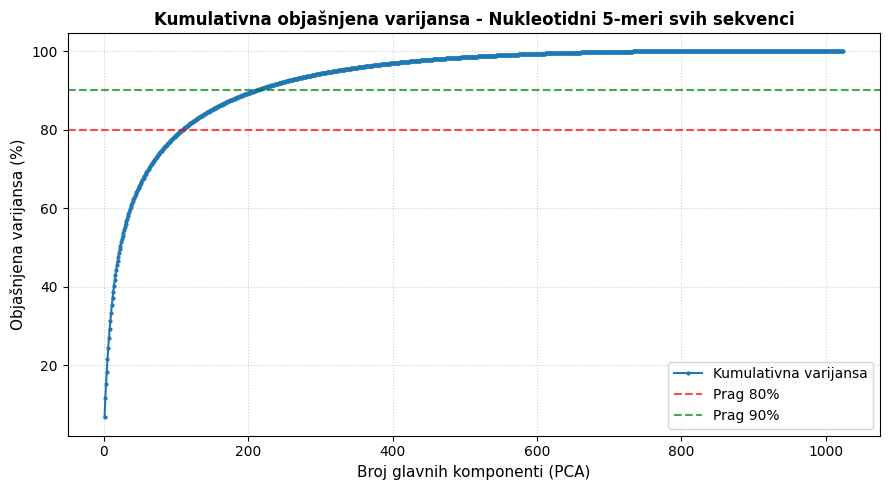

[Nukleotidni 5-meri svih sekvenci] Broj komponenti za 80% varijanse: 109
[Nukleotidni 5-meri svih sekvenci] Broj komponenti za 90% varijanse: 211


In [9]:
plot_cumulative_variance(all_5_mers,'Nukleotidni 5-meri svih sekvenci')

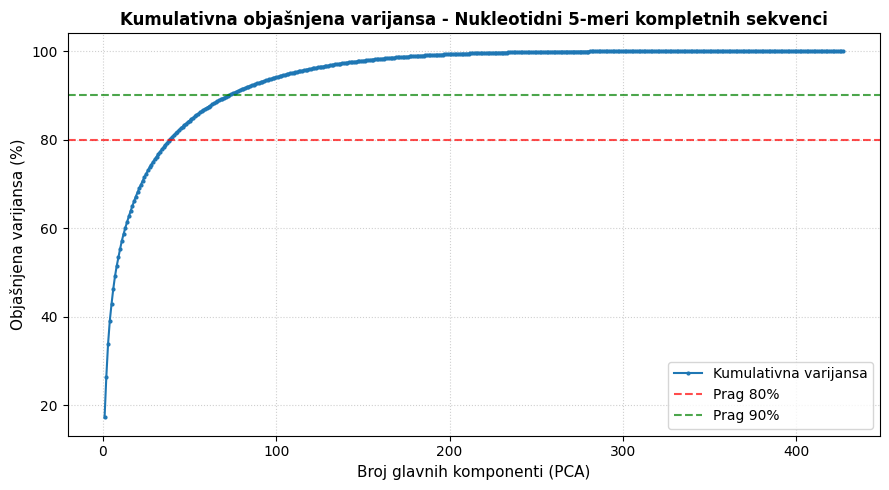

[Nukleotidni 5-meri kompletnih sekvenci] Broj komponenti za 80% varijanse: 39
[Nukleotidni 5-meri kompletnih sekvenci] Broj komponenti za 90% varijanse: 73


In [10]:
plot_cumulative_variance(complete_5_mers,'Nukleotidni 5-meri kompletnih sekvenci')

Analiza redukcije dimenzionalnosti u proširenom prostoru od 1024 obeležja ($4^5$), PCA analiza nastavlja trend rasta raspršenosti podataka:

* **Skup svih sekvenci:**
  * Za dostizanje praga od 80% varijanse potrebno je **109 glavnih komponenti** (211 za 90%).
  * Znatno veći broj potrebnih komponenti u poređenju sa 4-merima (skok sa 50 na 109) oslikava snažan uticaj parcijalnih sekvenci, gde kombinacija dužih k-mera i kratkih parcijalnih sekvenci stvara veliku retkost (*sparsity*) matrice.

* **Skup kompletnih sekvenci:**
  * Za očuvanje 80% varijanse potrebno je **39 komponenti** (73 za 90%).

#  Analiza 5-mera kompletnih nukleotida

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 8
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.3668
Davies-Bouldin Index: 1.4640
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.3738
Davies-Bouldin Index: 1.3392
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: full
----------------------------------------
Silhouette Score: 0.3558
Davies-Bouldin Index: 1.4229
5. Generisanje uporednog 3D prikaza...


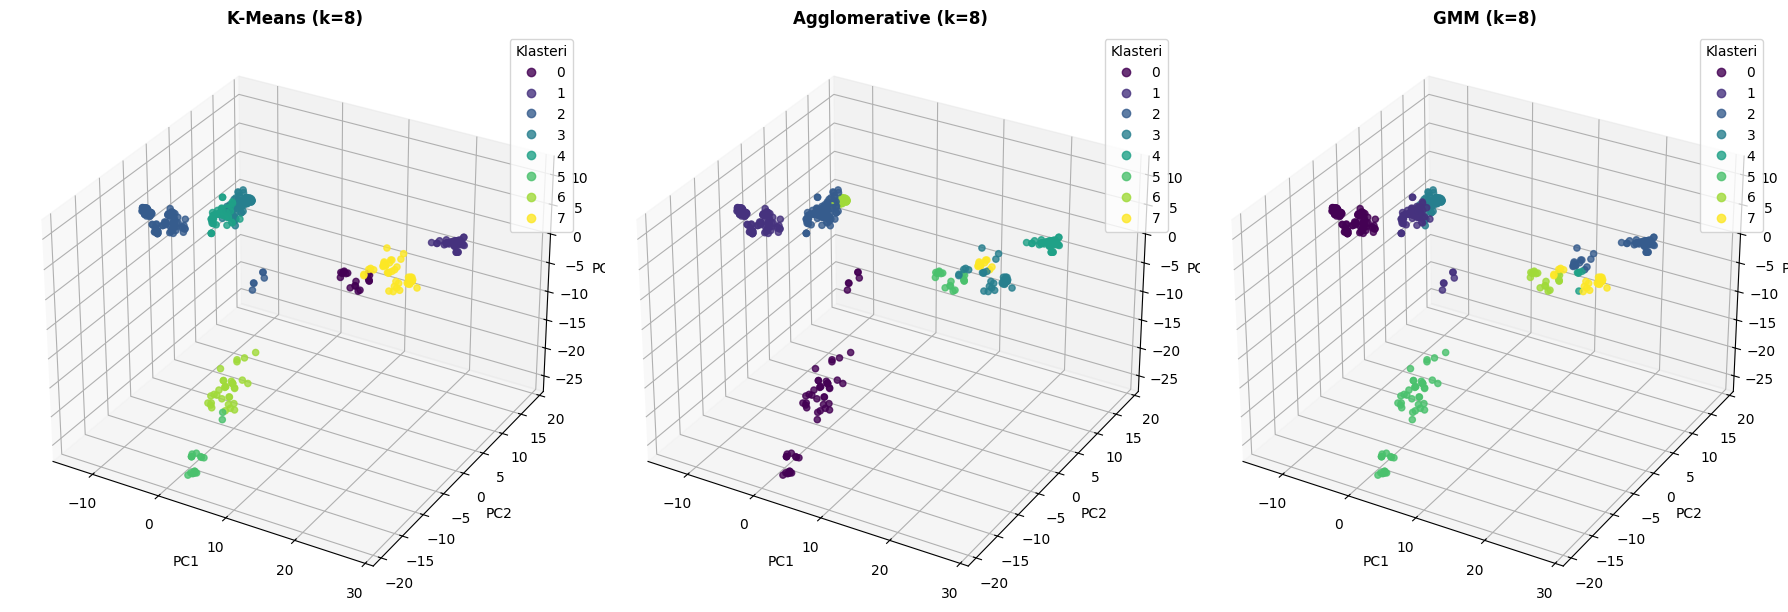

In [11]:
res_complete = run_hantavirus_clustering_pipeline(complete_5_mers, n_components=0.8, plot=True)

### Poređenje rezultata klasterovanja (5-meri kompletnih sekvenci, N = 427)
**Saglasnost algoritama $k = 8$:** Sva tri primenjena algoritma (K-Means, Aglomerativni i GMM) ponovo imaju 8 klastera (kao i u slučaju 4-mera).

**Metrike:** Aglomerativni model (Ward) postiže najbolju separaciju (Silueta = 0.3738, DB = 1.3392), dok K-Means i GMM ostvaruju iste rezultate (Silueta = 0.4171, DB = 1.0587). K-Means postiže siluetu od 0.3668 (DB = 1.4640), dok GMM beleži 0.3558 (DB = 1.4229).

**Poređenje sa 4-merima:** Dalji rast dimenzionalnosti (sa 256 na 1.024 obeležja) dovodi do očekivanog blagog pada silueta koeficijenta (sa ~0.43 na ~0.37) i rasta DB indeksa, usled raspršenosti podataka u znatno širem prostoru.

* **Opravdanost zadržavanja gornje granice na $k = 8$:**
  * Iako su sva tri modela najbolje rezulate dala za maksimalnu ispitivanoj vrednosti broja klastera ($k = 8$), pretraga nije proširivana na veće vrednosti.
  * Razlog leži u biološkoj strukturi uzorka (3 genetska segmenta i 4 vrste): uzimajući u obzir potpunu izolovanost L segmenta koji čini jedan nerazdvojiv klaster, $k = 8$ pruža optimalnu rezoluciju za istovremeno praćenje segmenata i izdvajanje vrsta na M i S segmentima.
  * Povećanje broja klastera iznad 8 u prostoru od 1024 k-mera bi moglo dovesti do veštačkog cepanja klastera, čime bi se narušila biološka interpretabilnost i poređenje sa analizama na $k = 3$ i $k = 4$.

In [12]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['kmeans'], 
    data= complete_5_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['agglomerative'], 
    data= complete_5_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_complete['labels']['gmm'], 
    data= complete_5_mers, 
    segments=res_complete['segments'], 
    species=res_complete['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,0,0,18
1,0,0,44
2,130,0,6
3,0,84,0
4,0,45,0
5,0,0,18
6,0,0,35
7,0,0,47



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,18,0,0,0
1,0,44,0,0
2,7,86,31,12
3,12,72,0,0
4,0,0,39,6
5,0,0,18,0
6,0,0,35,0
7,0,47,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 1 (N=44, pretežno S segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 2 (N=136, pretežno L segment) -> Orthohantavirus hantanense: 86 (63.2%), Orthohantavirus puumalaense: 31 (22.8%), Orthohantavirus sinnombreense: 12 (8.8%)
  Klaster 3 (N=84, pretežno M segment) -> Orthohantavirus hantanense: 72 (85.7%), Orthohantavirus dobravaense: 12 (14.3%)
  Klaster 4 (N=45, pretežno M segment) -> Orthohantavirus puumalaense: 39 (86.7%), Orthohantavirus sinnombreense: 6 (13.3%)
  Klaster 5 (N=18, pretežno S segment) -> Orthohantavirus puumalaense: 18 (100.0%)
  Klaster 6 (N=35, pretežno S segment) -> Orthohantavirus puumalaense: 35 (100.0%)
  Klaster 7 (N=47, pretežno S segment) -> Orthohantavirus hantanense: 47 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> GCCGC (Z=3.46), TGACC (Z=3.36), CGCTT (Z=3.28)
  Klaster 1 -> TGCGA (Z=

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=59, pretežno S segment) -> Orthohantavirus puumalaense: 53 (89.8%), Orthohantavirus sinnombreense: 6 (10.2%)
  Klaster 1 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 2 (N=85, pretežno M segment) -> Orthohantavirus puumalaense: 39 (45.9%), Orthohantavirus hantanense: 28 (32.9%), Orthohantavirus dobravaense: 12 (14.1%)
  Klaster 3 (N=35, pretežno S segment) -> Orthohantavirus hantanense: 35 (100.0%)
  Klaster 4 (N=44, pretežno S segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 5 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 6 (N=44, pretežno M segment) -> Orthohantavirus hantanense: 44 (100.0%)
  Klaster 7 (N=12, pretežno S segment) -> Orthohantavirus hantanense: 12 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> CTAAT (Z=1.92), CCCGC (Z=1.91), CCG

Segment,L,M,S
Cluster,,,
0,130,0,0
1,0,57,6
2,0,0,59
3,0,72,0
4,0,0,5
5,0,0,53
6,0,0,18
7,0,0,27



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,7,86,31,6
1,12,0,39,12
2,0,59,0,0
3,0,72,0,0
4,0,5,0,0
5,0,0,53,0
6,18,0,0,0
7,0,27,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=130, pretežno L segment) -> Orthohantavirus hantanense: 86 (66.2%), Orthohantavirus puumalaense: 31 (23.8%), Orthohantavirus dobravaense: 7 (5.4%)
  Klaster 1 (N=63, pretežno M segment) -> Orthohantavirus puumalaense: 39 (61.9%), Orthohantavirus dobravaense: 12 (19.0%), Orthohantavirus sinnombreense: 12 (19.0%)
  Klaster 2 (N=59, pretežno S segment) -> Orthohantavirus hantanense: 59 (100.0%)
  Klaster 3 (N=72, pretežno M segment) -> Orthohantavirus hantanense: 72 (100.0%)
  Klaster 4 (N=5, pretežno S segment) -> Orthohantavirus hantanense: 5 (100.0%)
  Klaster 5 (N=53, pretežno S segment) -> Orthohantavirus puumalaense: 53 (100.0%)
  Klaster 6 (N=18, pretežno S segment) -> Orthohantavirus dobravaense: 18 (100.0%)
  Klaster 7 (N=27, pretežno S segment) -> Orthohantavirus hantanense: 27 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> TAGAT (Z=1.19), TAGAG (Z=1.19), GTTAG (Z=1.14)
  Klaster 1 -> CTTGT (Z=1.59

### Interpretacija klastera (5-meri kompletnih sekvenci, N = 427)

Za detaljno tumačenje izabran je **K-Means ($k = 8$)**, uz poređenje sa aglomerativnim modelom i GMM-om:

* **L segment:** Kao i u slučaju 3-mera i 4-mera sva tri algoritma izdvajaju L segment u jedan klaster (Klaster 2 kod K-Means, gde se nalazi svih 130 L sekvenci roda uz 6 M sekvenci), dok je kod aglomerativnog i GMM-a svih 130 sekvenci izdvojeno u jedan čist klaster. Dominiraju motivi `TAGAG`, `GTTAG` i `TAGAT`.
* **M segment:** Kod svih modela M segment je podeljen na dva klastera:
  * Kod aglomerativnog modela, oba klastera su čisti M klasteri, gde se u jednom nalaze sve vrste virusa dok su u drugom zastupljene samo instance *O. hantanense* virusa.
  * Kod GMM modela, se u prvom M klasteru nalazi 57 M i 6 S instanci, dok je drugi potpuno sačinjen od M segmenata (njih 72), dok su vrste  raspoređene tako da su u drugom prisutne isključivo instance *O. hantanense*, a prvi čine instance ostalih virusa.
* **M segment K-Means:**
  * Klaster 3 objedinjuje M sekvence za *O. hantanense* (85.7%) i *O. dobravaense* (14.3%).
  * Klaster 4 grupiše *O. puumalaense* (86.7%) i *O. sinnombreense* (13.3%). Ova podela na dva klastera ponovo oslikava evolutivnu srodnost ovih parova virusa.
* **S segment K-Means:**  S segmenti se ponovo grupišu u 5 klastera tako da svaki klaster sadrži tačno jednu vrstu virusa (što važi i za GMM model).
  * *O. dobravaense* formira  čist Klaster 0 ($Z = 3.28 - 3.46$).
  * *O. puumalaense* se deli na dva podklastera (Klaster 5 sa 18 sekvenci i Klaster 6 sa 35 sekvenci), gde Klaster 5 dostiže ekstremno visoke Z-skorove (`CGCGT`, $Z = 4.73$).
  * *O. hantanense* se deli na dva podklastera (Klaster 1 sa 44 sekvence i Klaster 7 sa 47 sekvenci).

### Ključni 5-mer biomarkeri po klasterima (K-Means, N = 427)

| Klaster | Dominantni segment i vrsta | Ključni 5-meri | Raspon Z-skora | 
|---|---|---|---|
| **Klaster 0** | S: *O. dobravaense* (100%) | `GCCGC`, `TGACC` | 3.36 - 3.46 | 
| **Klaster 1** | S: *O. hantanense* (100%) | `TGCGA`, `AGGGG` | 2.41 - 2.52 | 
| **Klaster 2** | L segment, mešovite vrste | `TAGAG`, `GTTAG` | 1.12 - 1.13 | 
| **Klaster 3** | M: *O. hantanense* (85.7%) i *O. dobravaense* (14.3%) | `CCCCA`, `GTGCC` | 1.53 - 1.55 | 
| **Klaster 4** | M: *O. puumalaense* (86.7%) i *O. sinnombreense* (13.3%) | `AAAAA`, `CTTGT` | 1.76 - 1.79 |
| **Klaster 5** | S: *O. puumalaense* (100%) | `CGCGT`, `ACGCG` | 4.39 - 4.73 | 
| **Klaster 6** | S: *O. puumalaense* (100%) | `CCGCC`, `CCCGC` | 2.34 - 2.41 | 
| **Klaster 7** | S: *O. hantanense* (100%) | `TATGG`, `GACAG` | 1.92 - 1.96 | 


#  Analiza nukleotidnih 5-mera svih sekvenci

1. Pokretanje PCA redukcije dimenzionalnosti...
2. Izvršavanje K-Means klasterovanja...
=== NAJBOLJI K-MEANS REZULTATI ===
Optimalan broj klastera: 7
Način inicijalizacije: k-means++
----------------------------------------
Silhouette Score: 0.1569
Davies-Bouldin Index: 1.9490
****************************************
3. Izvršavanje Agglomerative klasterovanja...
=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 2
Izabrana metrika: euclidean
Tip povezivanja: average
----------------------------------------
Silhouette Score: 0.4484
Davies-Bouldin Index: 0.4181
****************************************
4. Izvršavanje GMM klasterovanja...
=== NAJBOLJI GMM REZULTATI ===
Optimalan broj klastera: 8
Tip kovarijanse: tied
----------------------------------------
Silhouette Score: 0.1215
Davies-Bouldin Index: 1.9252
5. Generisanje uporednog 3D prikaza...


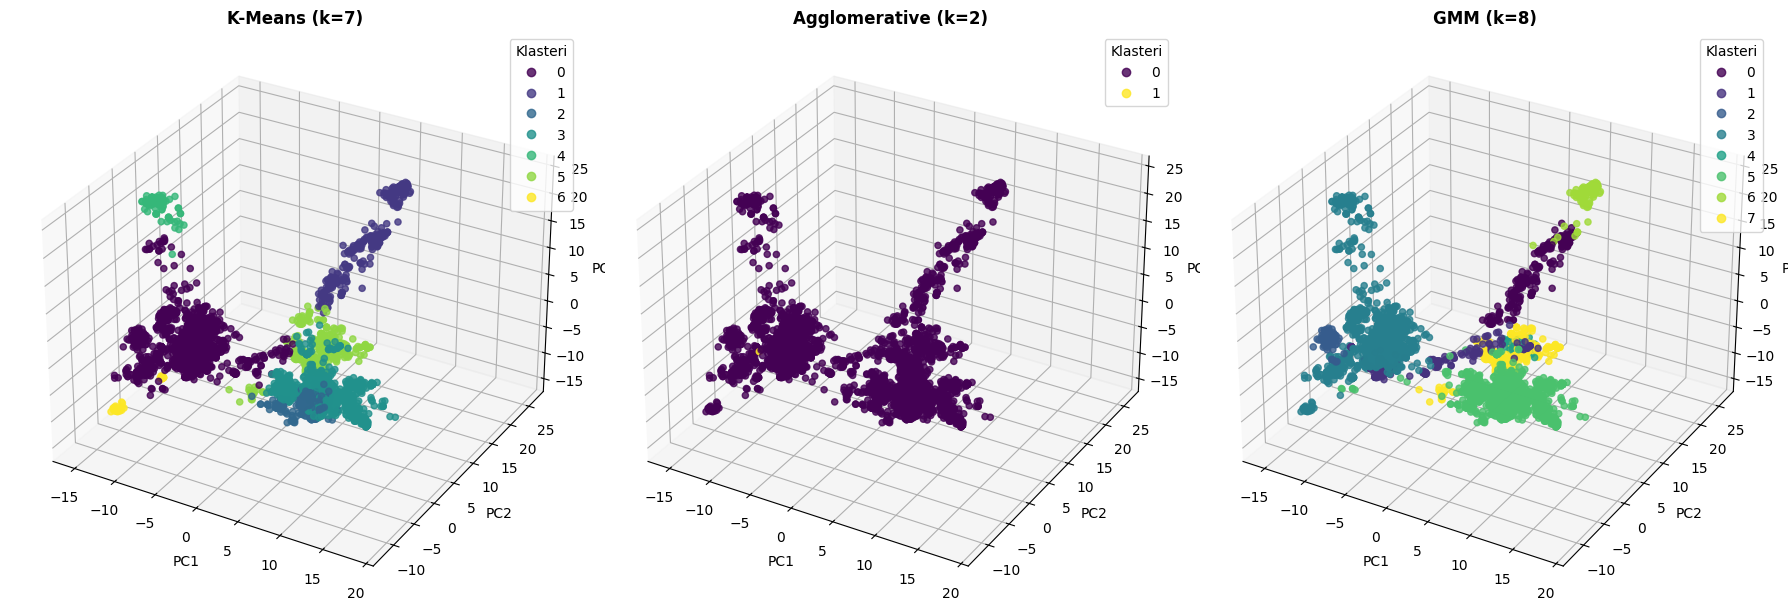

In [13]:
res_all = run_hantavirus_clustering_pipeline(all_5_mers, n_components=0.8, plot=True)

In [14]:
agg_single_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'],
    data=all_5_mers,
    segments=res_all['segments'],
    species=res_all['species'],
    model_name="Agglomerative (Single Linkage)"
)


========================= ANALIZA ZA: AGGLOMERATIVE (SINGLE LINKAGE) =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,880,1483,2815
1,1,0,0



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,438,1667,2827,246
1,0,0,1,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=5178, pretežno S segment) -> Orthohantavirus puumalaense: 2827 (54.6%), Orthohantavirus hantanense: 1667 (32.2%), Orthohantavirus dobravaense: 438 (8.5%)
  Klaster 1 (N=1, pretežno L segment) -> Orthohantavirus puumalaense: 1 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> ATGGA (Z=0.00), ATTGA (Z=0.00), AGACA (Z=0.00)
  Klaster 1 -> CGCGA (Z=43.42), GCGCG (Z=30.04), CGGCG (Z=14.74)


### Poređenje rezultata klasterovanja (5-meri svih sekvenci , N = 5179)

* **Uticaj dimenzionalnosti i parcijalnih sekvenci na separaciju i metrike (K-Means i GMM):**
  * Prelaskom na 1024 dimenzija i redukcijom na 109 PCA komponenti prostor 5-mera postaje izrazito redak pa silueta koeficijent dodatno opada u poređenju sa 4-merima, dok Davies-Bouldin indeks raste.

* **Problem jednostrukog povezivanja (Agglomerative - single linkage):**
  * Kao i u slučaju analize 3-mera i 4-mera dolazi ponovo do efekta lančanja pa je ponovo pokrenut algoritam sa wardovim povezivanjem.

In [21]:
best_params, best_metrics, agg_labels = optimize_and_print_agglomerative(
    res_all['X_pca'], 
    cluster_range=range(2, 9),
    linkages=['ward']
)

=== NAJBOLJI AGGLOMERATIVE REZULTATI ===
Optimalan broj klastera: 8
Izabrana metrika: euclidean
Tip povezivanja: ward
----------------------------------------
Silhouette Score: 0.1774
Davies-Bouldin Index: 1.9097


In [22]:
res_all['labels']['agglomerative'] = agg_labels
res_all['params']['agglomerative'] = best_params
res_all['metrics']['agglomerative'] = best_metrics

In [23]:
kmeans_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['kmeans'], 
    data= all_5_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="K-Means"
)

agg_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['agglomerative'], 
    data= all_5_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="Agglomerative"
)

gmm_analysis = analyze_clustering_results(
    cluster_labels=res_all['labels']['gmm'], 
    data= all_5_mers, 
    segments=res_all['segments'], 
    species=res_all['species'], 
    model_name="GMM"
)


========================= ANALIZA ZA: K-MEANS =========================

--- 1. Unakrsna tabela: Klasteri i genetski segmenti (L, M, S) ---


Segment,L,M,S
Cluster,,,
0,881,1265,81
1,0,0,280
2,0,0,470
3,0,0,1308
4,0,84,0
5,0,1,676
6,0,133,0



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,130,938,944,215
1,280,0,0,0
2,0,0,470,0
3,0,0,1281,27
4,0,84,0,0
5,28,645,0,4
6,0,0,133,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=2227, pretežno M segment) -> Orthohantavirus puumalaense: 944 (42.4%), Orthohantavirus hantanense: 938 (42.1%), Orthohantavirus sinnombreense: 215 (9.7%)
  Klaster 1 (N=280, pretežno S segment) -> Orthohantavirus dobravaense: 280 (100.0%)
  Klaster 2 (N=470, pretežno S segment) -> Orthohantavirus puumalaense: 470 (100.0%)
  Klaster 3 (N=1308, pretežno S segment) -> Orthohantavirus puumalaense: 1281 (97.9%), Orthohantavirus sinnombreense: 27 (2.1%)
  Klaster 4 (N=84, pretežno M segment) -> Orthohantavirus hantanense: 84 (100.0%)
  Klaster 5 (N=677, pretežno S segment) -> Orthohantavirus hantanense: 645 (95.3%), Orthohantavirus dobravaense: 28 (4.1%), Orthohantavirus sinnombreense: 4 (0.6%)
  Klaster 6 (N=133, pretežno M segment) -> Orthohantavirus puumalaense: 133 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> AAAGT (Z=0.75), TAAAT (Z=0.67), GTGTT (Z=0.67)
  Klaster 1 -> CGTGC (Z=2.95), TCGTG (Z=2.94), GCG

...


--- Dominantne vrste po klasterima ---
  Klaster 0 (N=2162, pretežno M segment) -> Orthohantavirus hantanense: 910 (42.1%), Orthohantavirus puumalaense: 876 (40.5%), Orthohantavirus sinnombreense: 246 (11.4%)
  Klaster 1 (N=646, pretežno S segment) -> Orthohantavirus hantanense: 646 (100.0%)
  Klaster 2 (N=1289, pretežno S segment) -> Orthohantavirus puumalaense: 1287 (99.8%), Orthohantavirus hantanense: 2 (0.2%)
  Klaster 3 (N=188, pretežno M segment) -> Orthohantavirus puumalaense: 188 (100.0%)
  Klaster 4 (N=308, pretežno S segment) -> Orthohantavirus dobravaense: 308 (100.0%)
  Klaster 5 (N=109, pretežno M segment) -> Orthohantavirus hantanense: 109 (100.0%)
  Klaster 6 (N=335, pretežno S segment) -> Orthohantavirus puumalaense: 335 (100.0%)
  Klaster 7 (N=142, pretežno S segment) -> Orthohantavirus puumalaense: 142 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> AAAGT (Z=0.75), TAAAT (Z=0.69), AAATT (Z=0.66)
  Klaster 1 -> CGTTG (Z=1.71), CCTGC (Z=1.70),

Segment,L,M,S
Cluster,,,
0,0,0,217
1,110,0,93
2,0,64,0
3,771,1418,3
4,0,0,34
5,0,0,1767
6,0,0,93
7,0,1,608



--- 2. Unakrsna tabela: Klasteri i vrste hantavirusa ---


Species,Orthohantavirus dobravaense,Orthohantavirus hantanense,Orthohantavirus puumalaense,Orthohantavirus sinnombreense
Cluster,,,,
0,215,2,0,0
1,0,0,110,93
2,0,0,64,0
3,130,1019,890,153
4,0,34,0,0
5,0,3,1764,0
6,93,0,0,0
7,0,609,0,0



--- Dominantne vrste po klasterima ---
  Klaster 0 (N=217, pretežno S segment) -> Orthohantavirus dobravaense: 215 (99.1%), Orthohantavirus hantanense: 2 (0.9%)
  Klaster 1 (N=203, pretežno L segment) -> Orthohantavirus puumalaense: 110 (54.2%), Orthohantavirus sinnombreense: 93 (45.8%)
  Klaster 2 (N=64, pretežno M segment) -> Orthohantavirus puumalaense: 64 (100.0%)
  Klaster 3 (N=2192, pretežno M segment) -> Orthohantavirus hantanense: 1019 (46.5%), Orthohantavirus puumalaense: 890 (40.6%), Orthohantavirus sinnombreense: 153 (7.0%)
  Klaster 4 (N=34, pretežno S segment) -> Orthohantavirus hantanense: 34 (100.0%)
  Klaster 5 (N=1767, pretežno S segment) -> Orthohantavirus puumalaense: 1764 (99.8%), Orthohantavirus hantanense: 3 (0.2%)
  Klaster 6 (N=93, pretežno S segment) -> Orthohantavirus dobravaense: 93 (100.0%)
  Klaster 7 (N=609, pretežno S segment) -> Orthohantavirus hantanense: 609 (100.0%)

--- 3. Top 3 k-mera po Z-skoru po klasterima ---
  Klaster 0 -> CCATC (Z=2.75), TTGA

### Interpretacija klastera (5-meri svih sekvenci, N = 5179)

Kao reprezentativni model izabran je **K-Means ($k = 7$)**, pri čemu aglomerativni model (Ward, $k = 8$) i GMM ($k = 8$) pokazuju slične rezultate:

* **Spajanje M i L segmenta (Klaster 0):** Svih 881 L sekvenci je grupisano u Klaster 0 zajedno sa većinom M sekvenci (1265) i nekoliko S sekvenci (81). Zbog velike brojnosti ($N = 2227$) i mešavine segmenata i vrsta, Z-skorovi motiva u ovom klasteru su niski ($Z \approx 0.67 - 0.75$).
* **M segment:** Pored prisustva u velikom mešovitom klasteru 0, M segment se uspešno cepa na dva skroz čista specifična klastera:
  * Klaster 4: 84 M sekvence specifične isključivo za *O. hantanense* (100%), uz izuzetno visok Z-skor motiva `ACCGC` ($Z = 5.04$).
  * Klaster 6: 133 M sekvence specifične isključivo za *O. puumalaense* (100%), definisane motivom `TCTCT` ($Z = 4.20$).
* **S segment:** 
  * *O. dobravaense* formira čist Klaster 1 ($N = 280$) sa karakterističnim CpG motivima `CGTGC` ($Z = 2.95$) i `TCGTG` ($Z = 2.94$).
  * *O. hantanense* formira Klaster 5 sa 95.3% čistoće.
  * *O. puumalaense* se, zbog velike brojnosti, deli na manji čist Klaster 2 ($N = 470$) i veći Klaster 3 ($N = 1308$, 97.9% čistoće).
* **Malobrojne vrste:**
  * Iako su i *O. dobravaense* i *O. sinnombreense* slabo zastupljene, *O. dobravaense* formira čist klaster zahvaljujući većem broju S segmenata, koji dobro razdvajaju vrste virusa.

### Ključni 5-mer biomarkeri po klasterima (K-Means, N = 5179)

| Klaster | Dominantni segment i vrsta | Ključni 5-meri | Raspon Z-skora |
|---|---|---|---|
| **Klaster 0** | L (100% L sekvenci) + mešoviti M/S | `AAAGT`, `TAAAT` | 0.67 - 0.75 | 
| **Klaster 1** | S: *O. dobravaense* (100%) | `CGTGC`, `TCGTG` | 2.94 - 2.95 | 
| **Klaster 2** | S: *O. puumalaense* (100%) | `CCTAC`, `CGTAA` | 1.96 - 2.14 | 
| **Klaster 3** | S: *O. puumalaense* (97.9%) | `ACTTC`, `GGTAT` | 1.06 - 1.08 |
| **Klaster 4** | M: *O. hantanense* (100%) | `ACCGC`, `CGTCT` | 4.89 - 5.04 | 
| **Klaster 5** | S: *O. hantanense* (95.3%) | `CGTTG`, `GGTGG` | 1.63 - 1.67 |
| **Klaster 6** | M: *O. puumalaense* (100%) | `TCTCT`, `CTAGG` | 3.77 - 4.20 | 


# Čuvanje rezultata

In [25]:
row_complete = extract_kmer_summary(res_complete, k_val=5, dataset_type='Complete')

In [26]:
row_all = extract_kmer_summary(res_all, k_val=5, dataset_type='All')

In [27]:
summary_5_mers = pd.DataFrame([row_complete, row_all])

In [29]:
output_path = '../data/sequences_kmers/summary_5_mers.csv'
summary_5_mers.to_csv(output_path, index=False)

In [30]:
summary_5_mers

,k,Dataset,Features,PCA_comps,KMeans_k,KMeans_Sil,KMeans_DB,GMM_k,GMM_Sil,GMM_DB,Agg_k,Agg_linkage,Agg_Sil,Agg_DB
0,5,Complete,1024,39,8,0.3668,1.464,8,0.3558,1.4229,8,ward,0.3738,1.3392
1,5,All,1024,109,7,0.1569,1.949,8,0.1215,1.9252,8,ward,0.1774,1.9097
